# Roemer's determination of the speed of light

Plot a schematic of the true relative postions of the Earth and Jupiter at opposition on 1673 Apr 2 and
~6 months later near conjunction on 1673 Oct 2.  This was during the period from 1671 to 1673 when Ole Roemer
made his observations of the timing of eclipses of Io by Jupiter that led to the first estimate of the
finite speed of light.

Also plot the data for the oppositions seasons of 1672 March 2 and 1673 April 2 that were the critical
observations analyzed by Romer.

Based on observations made at the Paris observatory by Romer and Jean Picard, Romer computed that the time for 
light to travel the diameter of Earth's orbit was **22 minutes**. He used this to successfully predict that the 
emersion of Io's eclipse on 1676 Nov 9 would occur 10 minutes later than predicted, and it was so observed.  An
account of this report to the French Academy of the Sciences as reported in the 1676 Dec 7 edition of the 
*Journal des Scavans*, and an English-translation was communicated to the British Royal Society in the 
[*Philosophical Transactions* of 1677 June 25](https://royalsocietypublishing.org/doi/10.1098/rstl.1677.0024).

The relevant quote from the *Journal des Scavans* is:
 > "... & ce a raison de **22** pour tout l'intervalle H E, qui est le double de celuy qu'il y a d'icy au Soleil."

and the translation in the *Philosophical Transactions*:
 
 > "... and that in proportion of **twenty two** for the whole interval of H E, which is the double of the intervale that is from hence to the Sun."

For a detailed discussion see [Bernard Cohen's 1940 paper in Isis, Vo. 31, pp. 327-379](https://www.jstor.org/stable/225757)). 

## Romer's Data

Most of Romer's records were lost in the Copenhagen Fire of 1728, but a surviving manuscript folio in
Romer's hand was found in 1913 by Kirstine Meyer (Meyer, 1915, *Om Ole Rømers Opdagelse af Lysets Tøven, Det 
Kongelige Danske Videnskabernes Selskabs Skrifter*, 7. Række, naturvidenskabelig og mathematisk Afdeling, XII. 
3, København).

<img src="RomerData_1913.jpg" width="800">

Entitled *Obser. Primi Jovialium Parisiis* (Observations of the first Jupiter moon in Paris), it was written
in Romer's hand around 1678 and appears to be Romer's *aide memoir* (aka cheat sheet) showing the summary data
for the immersions and emersions of Io observed from the Paris observatory by Picard and Romer between 1688
and 1678. A follow-up work by Romer to fully describe the results was apparently planned but never completed. 

Of interest to us here are the observations around the two critical oppositions in 1672 and 1673 that formed
the basis of Romer's measurements, and the famous measurement of 1676 Nov 9 for which Romer predicted a 10
minute delay due to the finite speed of light (curiously, Romer appears to have flipped minutes/seconds parts
of the time of emersion that appears in the surviving manuscript compared to the time reported by the *Journal 
des Scavans* and the *Philosophical Transactions*).

We're using the [high-resolution scan of this document](https://commons.wikimedia.org/wiki/File:Ole_R%C3%B8mer_-_Obser._Primi_Jovialium_Parisiis_-_pp1%2B4.jpg) that was uploaded to Wikipedia.


## Modern Data

We derived high-precision positions of Earth and Jupiter for the period 1668 through 1678 using the 
JPL Horizons System, which was developed at the Jet Propulsion Laboratory (Solar System Dynamics Group), California Institute of Technology, under contract with the National Aeronautics and Space Administration.

Positions for the dates of Romer's observations during this time are for UTC midnight, which is essentially
midnight in Paris at the time - close enough for our purposes.

Giorgini, JD and JPL Solar System Dynamics Group, NASA/JPL Horizons On-Line Ephemeris System, 
https://ssd.jpl.nasa.gov/horizons/.

In [8]:
%matplotlib inline

import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)
warnings.filterwarnings('ignore',category=RuntimeWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Figure Filename

`figName` sets the filename of any hardcopy files.

#### Production and Draft Figures

Set `makePNG = True` to make a 600dpi PNG, `False` to create an EPS file

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3.

Typical values of `aspect` by plot type:
 * 4:3 aspect for single-panel landscape plots
 * 2.5 for spectra
 * 1.8 or 2 for side-by-side 2- and 3-panel plots.
 * 1.0
 
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

You must use `ax.set_aspect(True)` to ensure equal aspect ratio when plotting Cartesian coordinates.

In [9]:
# graphic aspect ratio = width/height

aspect = 1.0

# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)


# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Read the data

Data is a vector file created by the JPL Horizons database.  We edited out the descriptive header and footer
and gave it a new header for easier reading by `pandas.read_csv()`.

In [10]:
# orbits

orbFile = 'Jupiter_1673_1685.txt'
data = pd.read_csv(orbFile)
xJupOrb = np.array(data['X'])
yJupOrb = np.array(data['Y'])
zJupOrb = np.array(data['Z'])

earthFile = 'Earth_1673.txt'
data = pd.read_csv(earthFile)
xEarth = np.array(data['X'])
yEarth = np.array(data['Y'])
zEarth = np.array(data['Z'])
tdbEarth = np.array(data['TDB'])

jupFile = 'Jupiter_1673.txt'
data = pd.read_csv(jupFile)
xJup = np.array(data['X'])
yJup = np.array(data['Y'])
zJup = np.array(data['Z'])
tdbJup = np.array(data['TDB'])

# All observations from 1671 to 1673

reFile = 'Earth_1671_1673_Romer.txt'
data = pd.read_csv(reFile)
xrEarth = np.array(data['X'])
yrEarth = np.array(data['Y'])
zrEarth = np.array(data['Z'])

rjFile = 'Jupiter_1671_1673_Romer.txt'
data = pd.read_csv(rjFile)
xrJup = np.array(data['X'])
yrJup = np.array(data['Y'])
zrJup = np.array(data['Z'])
obsDate = np.array(data['TDB'])

numObs = len(xrEarth)

# 1672 opposition (includes late 1671)

reFile = 'Earth_1672opp_Romer.txt'
data = pd.read_csv(reFile)
xrE_1672 = np.array(data['X'])
yrE_1672 = np.array(data['Y'])
zrE_1672 = np.array(data['Z'])

rjFile = 'Jupiter_1672opp_Romer.txt'
data = pd.read_csv(rjFile)
xrJ_1672 = np.array(data['X'])
yrJ_1672 = np.array(data['Y'])
zrJ_1672 = np.array(data['Z'])
obsDate_1672 = np.array(data['TDB'])

num1672 = len(xrE_1672)

# 1673 opposition (includes late 1672)

reFile = 'Earth_1673opp_Romer.txt'
data = pd.read_csv(reFile)
xrE_1673 = np.array(data['X'])
yrE_1673 = np.array(data['Y'])
zrE_1673 = np.array(data['Z'])

rjFile = 'Jupiter_1673opp_Romer.txt'
data = pd.read_csv(rjFile)
xrJ_1673 = np.array(data['X'])
yrJ_1673 = np.array(data['Y'])
zrJ_1673 = np.array(data['Z'])
obsDate_1673 = np.array(data['TDB'])

num1673 = len(xrE_1673)

# 1676-Nov-09 observation JPL Horizons Data

xE_1676 = 6.029229715574349E-01
yE_1676 = 7.821447655928592E-01
zE_1676 = 7.595355580814606E-04

xJ_1676 = 2.748747956963356
yJ_1676 = -4.300901096978589
zJ_1676 = -4.503557872235291E-02

dX_1676 = xJ_1676 - xE_1676
dY_1676 = yJ_1676 - yE_1676
dZ_1676 = zJ_1676 - zE_1676

dEJ_1676 = np.sqrt(dX_1676*dX_1676 + dY_1676*dY_1676 + dZ_1676*dZ_1676)

print(f'1676-Nov-09 d_EJ = {dEJ_1676:.4f} au')

reFile = 'Earth_Jul1676.txt'
data = pd.read_csv(reFile)
xrE_Jul1676 = np.array(data['X'])
yrE_Jul1676 = np.array(data['Y'])
zrE_Jul1676 = np.array(data['Z'])

rjFile = 'Jupiter_Jul1676.txt'
data = pd.read_csv(rjFile)
xrJ_Jul1676 = np.array(data['X'])
yrJ_Jul1676 = np.array(data['Y'])
zrJ_Jul1676 = np.array(data['Z'])

obsDate_Jul1676 = np.array(data['TDB'])

dX = xrE_Jul1676 - xrJ_Jul1676
dY = yrE_Jul1676 - yrJ_Jul1676
dZ = zrE_Jul1676 - zrJ_Jul1676

dEJ_Jul1676 = np.sqrt(dX*dX + dY*dY + dZ*dZ)

#for i in range(len(dEJ_Jul1676)):
#    print(f'{obsDate_Jul1676[i]} {dEJ_Jul1676[i]:.4f}au delta={dEJ_Jul1676[i]-dEJ_1676:.6f} au')

# Earth-Jupiter distance

dX = xJup - xEarth
dY = yJup - yEarth
dZ = zJup - zEarth

dEJ = np.sqrt(dX*dX + dY*dY + dZ*dZ)

# Opposition in 1673 on 1673-Apr-02

tdbOpp = '1673-Apr-02'
iOpp = np.where(tdbJup==tdbOpp)[0]

# Near-conjunction on ...

tdbCon = '1673-Oct-02'
iCon = np.where(tdbJup==tdbCon)[0]

print(f'd_Opp = {dEJ[iOpp][0]:.2f} au')
print(f'd_Con = {dEJ[iCon][0]:.2f} au')

dX = dEJ[iCon][0]-dEJ[iOpp][0]

print(f'EJ(Con)-EJ(Opp) = {dX:.3f} au')

dTromer = 22.0 # minutes
print(f'\nRomer time delay: dT = {dTromer:.0f} min')

au = 1.49597870700e11 # m
secMin = 60.0 # sec/min
c_SI = 2.99792458e8 # m/s

c_aum = 2/22
c_mks = c_aum*au/secMin

c_mks_SI = 100*(c_mks/c_SI)

print(f'c_romer = {c_aum:.5f} au/min = {c_mks:.6e} m/s = {c_mks_SI:.1f}% c')

# actual time delay

dT_true = 2*au/c_SI/60

print(f'actual time delay = {dT_true:.2f} minutes')


1676-Nov-09 d_EJ = 5.5176 au
d_Opp = 4.45 au
d_Con = 6.39 au
EJ(Con)-EJ(Opp) = 1.946 au

Romer time delay: dT = 22 min
c_romer = 0.09091 au/min = 2.266634e+08 m/s = 75.6% c
actual time delay = 16.63 minutes


## Orbits of Jupiter and Earth

Plot the orbits of Earth and Jupiter, then positions of both at
 * opposition on 1673-Apr-02
 * near-conjunction on 1673-Oct-02 ~6 months later
 
Draw the lines of the Earth-Jupiter distance at each configuration.

This plot is for illustration purposes, as will become clear in later sections of this notebook. Of the two,
only 1673 April 2 is during Romer's second season of Io eclipse observations which ran from 28 Nov 1672
through 4 Aug 1673, but he made no observations on that date, and his observations ended in August, well
before the October 6 date for this plot.

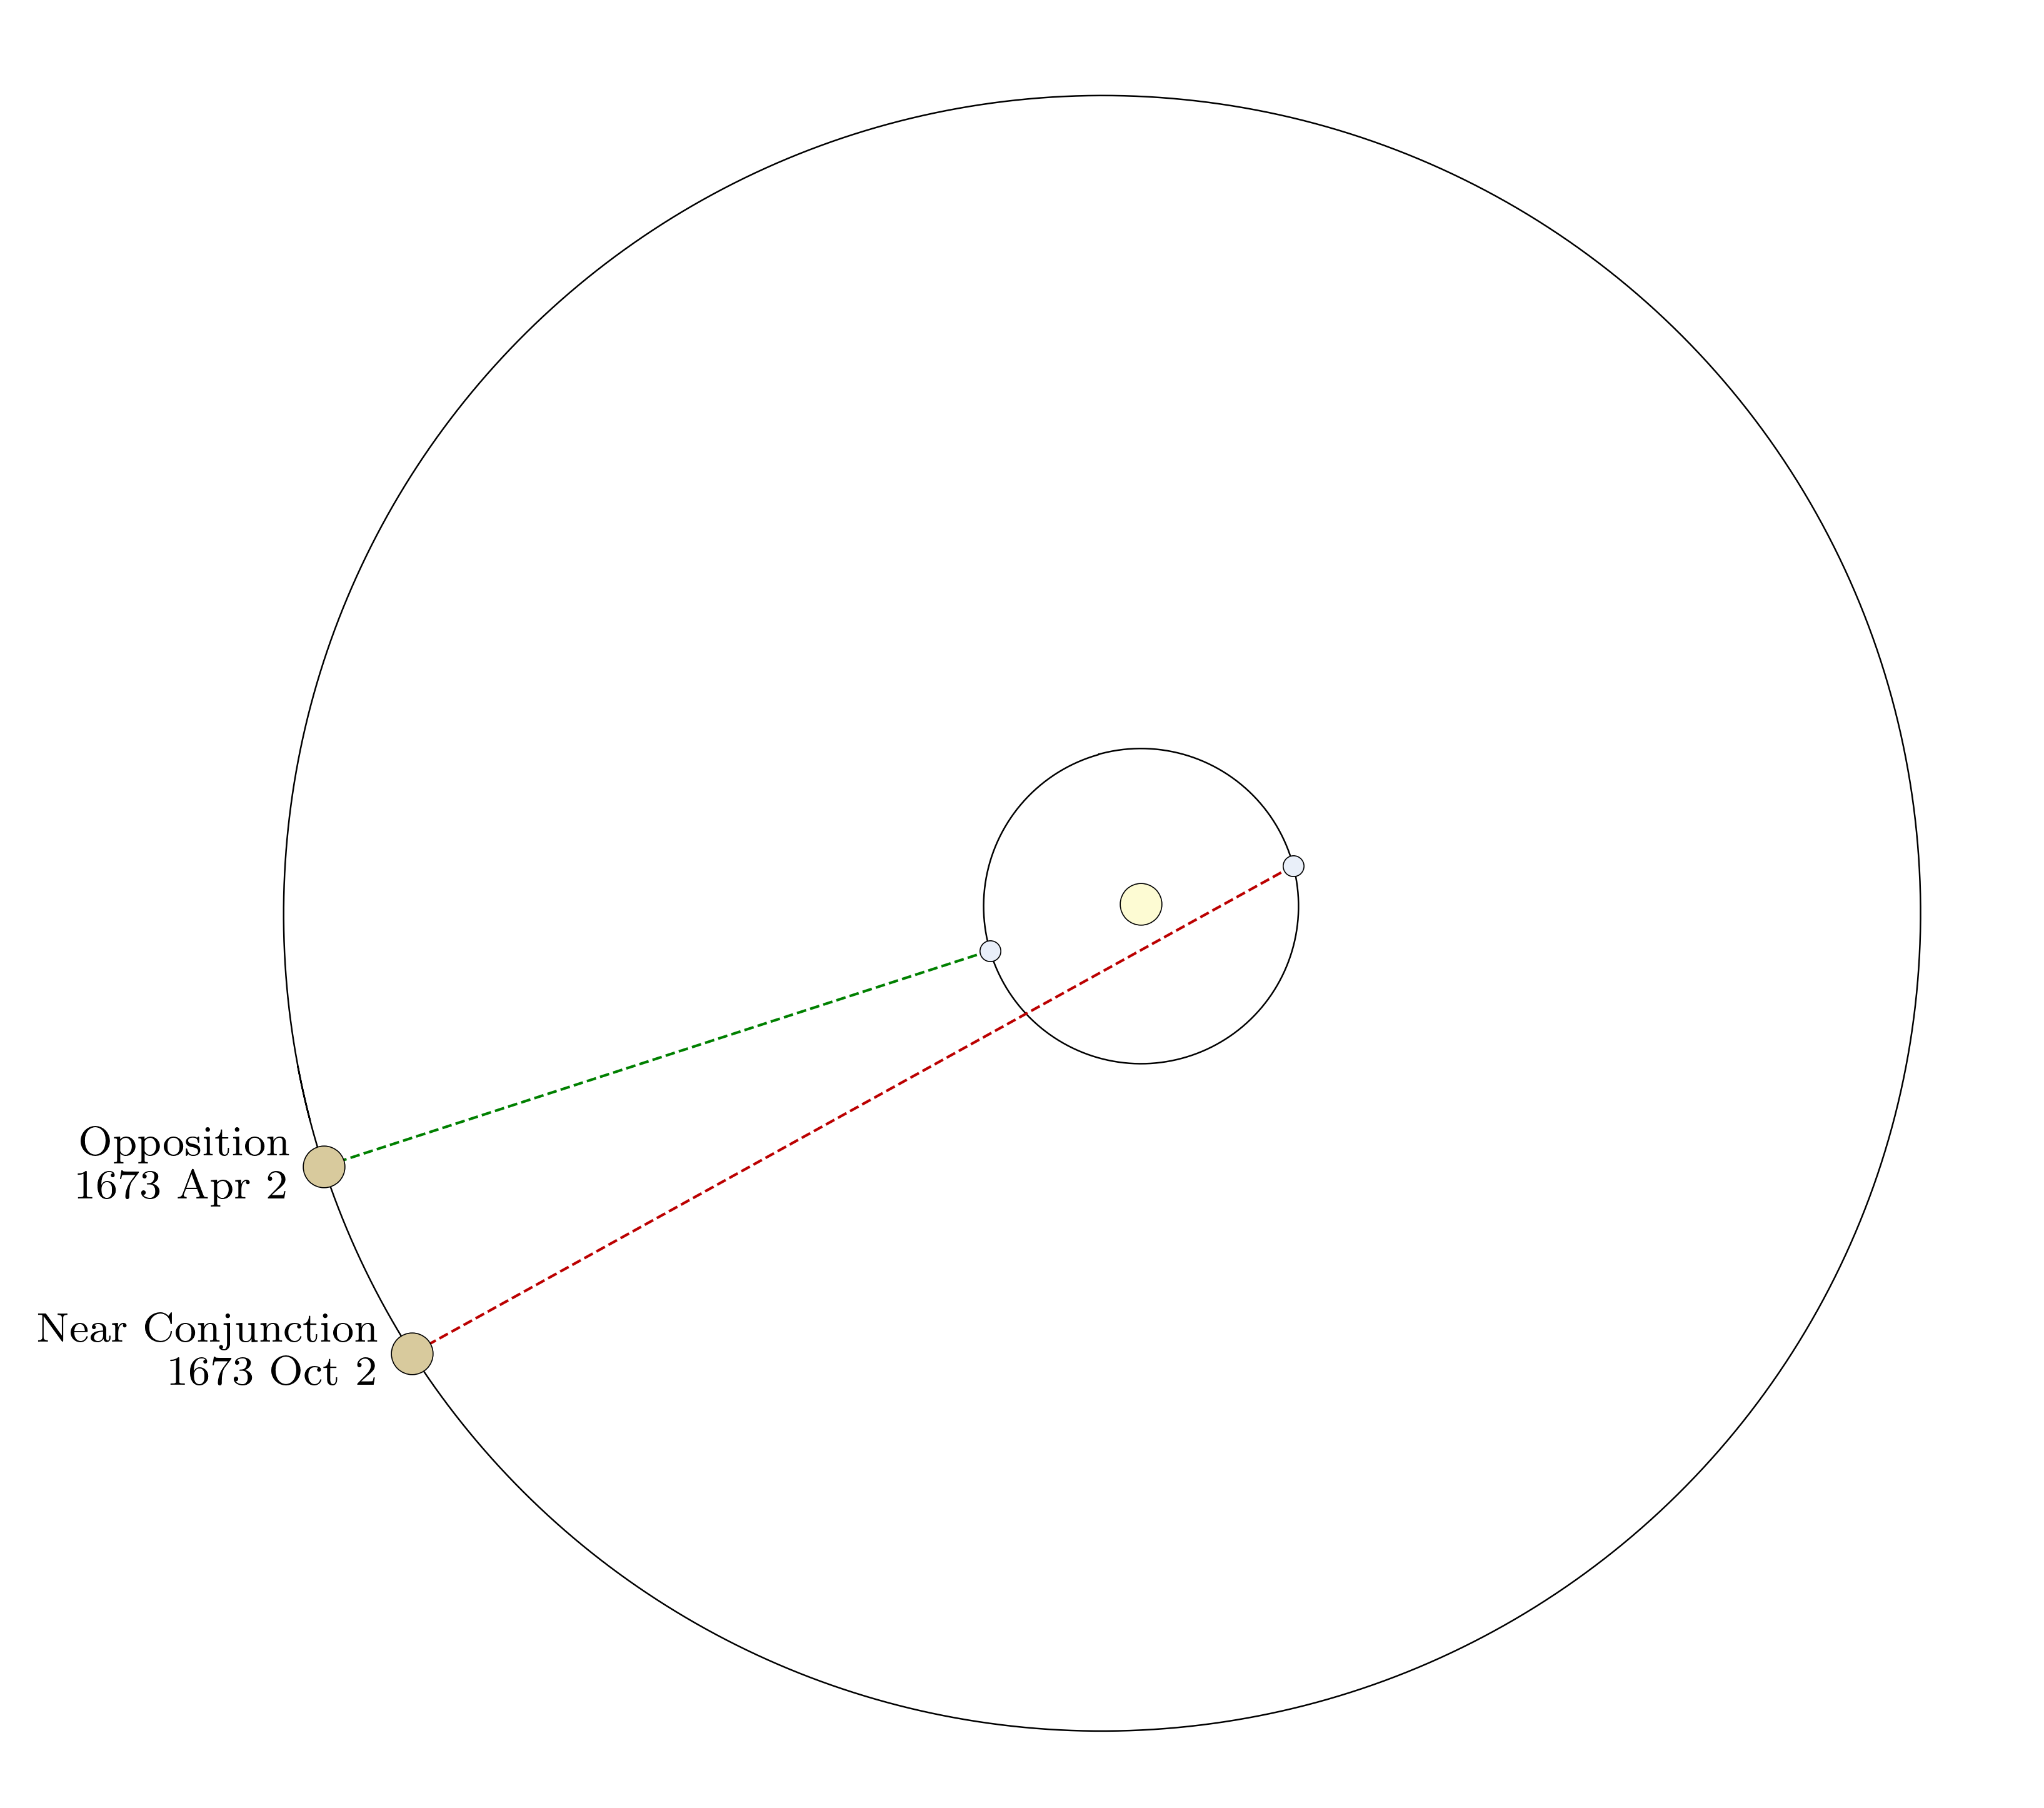

In [11]:
plotFile = 'EarthJupiter_1673.png'

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax.set_aspect(True)  

# 1:1 axis ratio

ax.set_xlim(-5.5,5.5)
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_ylim(-5.5,5.5)
ax.set_yticks([])
ax.set_yticklabels([])
ax.axis('off')

# plot the orbits of Earth and Jupiter

ax.plot(xEarth,yEarth,'-',color='black',lw=0.3,zorder=8)
ax.plot(xJupOrb,yJupOrb,'-',color='black',lw=0.3,zorder=8)

# Sun at the center

ax.plot(0,0,'o',ms=8,mfc='#fdfbd3',mec='black',mew=0.2,zorder=10)

# positions of Earth and Jupiter at opposition on 1673-Apr-02

ax.plot(xEarth[iOpp],yEarth[iOpp],'o',ms=4,mfc='#e9eff9',mec='black',mew=0.2,zorder=10)
ax.plot(xJup[iOpp],yJup[iOpp],'o',ms=8,mfc='#d8ca9d',mec='black',mew=0.2,zorder=10)
ax.plot([xEarth[iOpp],xJup[iOpp]],[yEarth[iOpp],yJup[iOpp]],'--',color='green',lw=0.5,zorder=8)

ax.text(xJup[iOpp]-0.2,yJup[iOpp],'Opposition\n1673 Apr 2',ha='right',va='center',fontsize=labelFontSize)

# positions of Earth and Jupiter at conjunction ~6 months later

ax.plot(xEarth[iCon],yEarth[iCon],'o',ms=4,mfc='#e9eff9',mec='black',mew=0.2,zorder=10)
ax.plot(xJup[iCon],yJup[iCon],'o',ms=8,mfc='#d8ca9d',mec='black',mew=0.2,zorder=10)
ax.plot([xEarth[iCon],xJup[iCon]],[yEarth[iCon],yJup[iCon]],'--',color='#bb0000',lw=0.5,zorder=8)

ax.text(xJup[iCon]-0.2,yJup[iCon],'Near Conjunction\n1673 Oct 2',ha='right',va='center',fontsize=labelFontSize)

# make the hardcopy

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

## Romer's observations

Data from Romer's *Obser. Primi Jovialium Parisiis* (Meyer, Kirstine (1915) *Om Ole Rømers Opdagelse af Lysets
Tøven, Det Kongelige Danske Videnskabernes Selskabs Skrifter*, 7. Række, naturvidenskabelig og mathematisk 
Afdeling, XII. 3, København.)


### All data from 1671 through 1673

These data cover the oppositions in 1672 and 1673 that formed the basis of Romer's measurement.  We plot
the positions from the JPL Horizons calculations in pairs connected by lines.  A bit of a mess but shows
all the groupings by oppositions.  Observations were made from the first (eastern) quadrature through second
(western) quadrature around opposition.

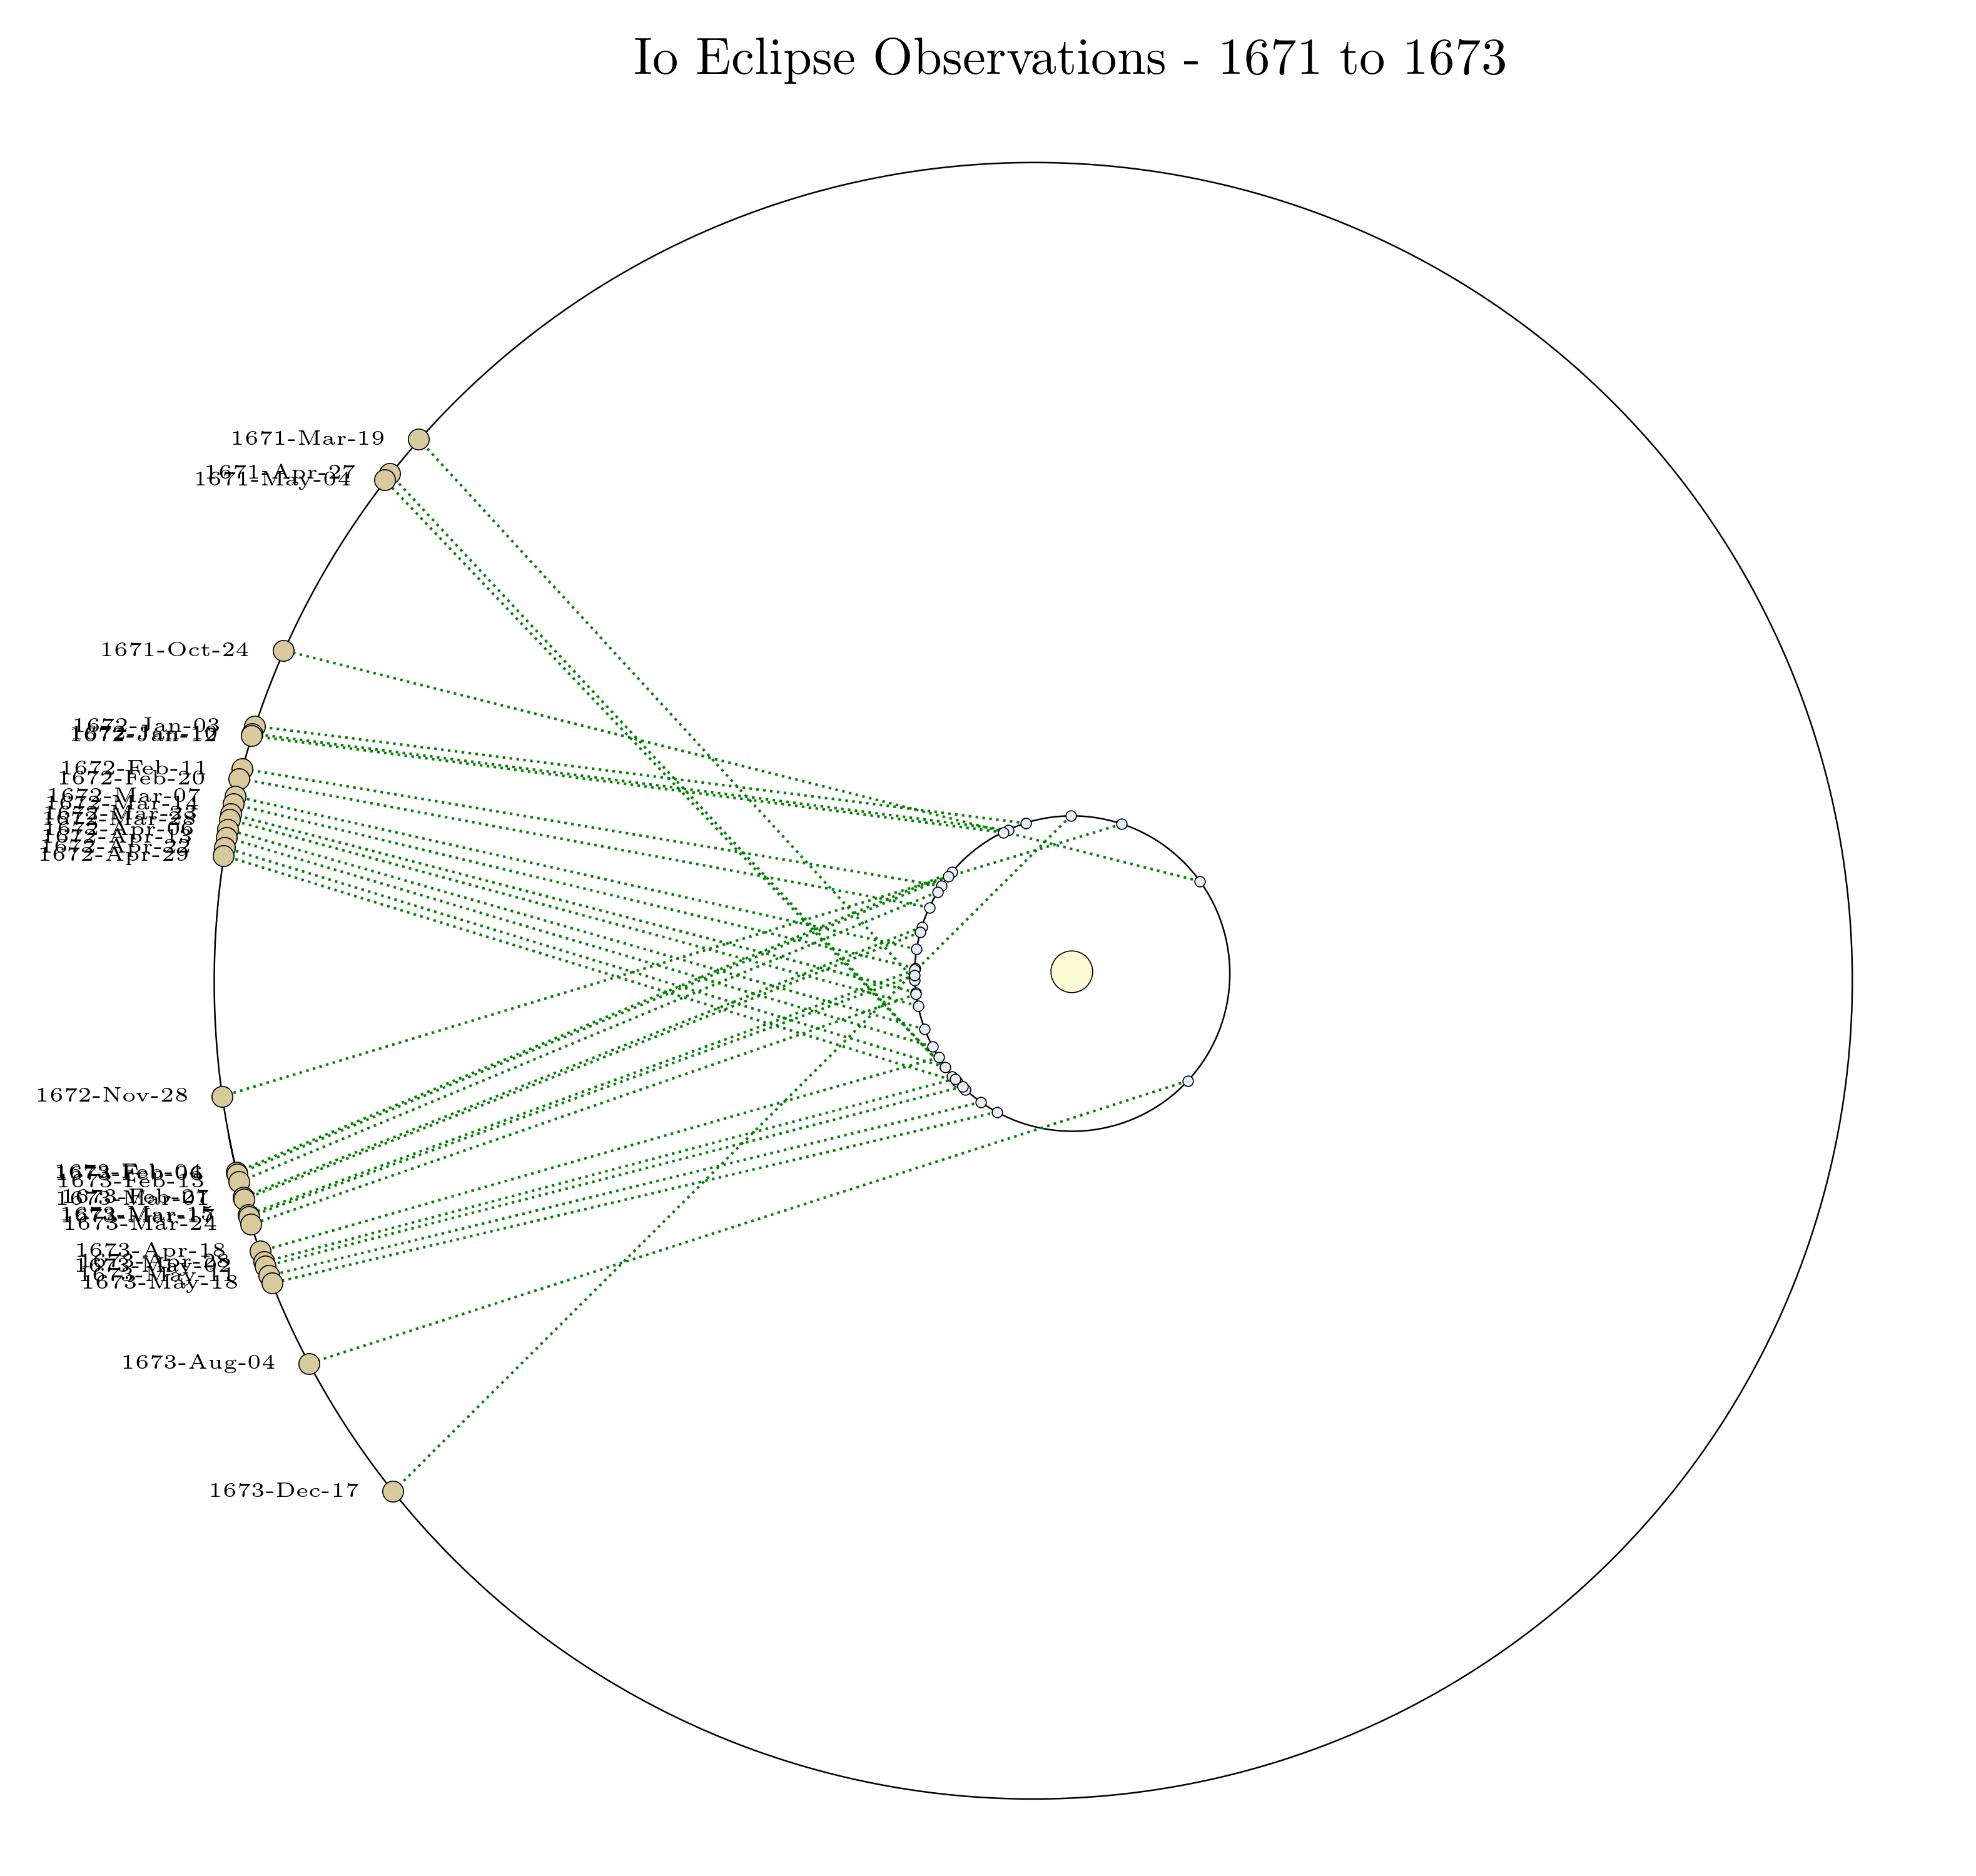

In [12]:
plotFile = 'EarthJupiter_RomerObs.png'

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax.set_aspect(True)  

# 1:1 axis ratio

ax.set_xlim(-5.5,5.5)
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_ylim(-5.5,5.5)
ax.set_yticks([])
ax.set_yticklabels([])

ax.axis('off')

# plot the orbits of Earth and Jupiter

ax.plot(xEarth,yEarth,'-',color='black',lw=0.3,zorder=8)
ax.plot(xJupOrb,yJupOrb,'-',color='black',lw=0.3,zorder=8)

# Sun at the center

ax.plot(0,0,'o',ms=8,mfc='#fdfbd3',mec='black',mew=0.2,zorder=10)

# positions of Earth and Jupiter during Romer's observations

for i in range(numObs):
    ax.plot(xrEarth[i],yrEarth[i],'o',ms=2,mfc='#e9eff9',mec='black',mew=0.2,zorder=10)
    ax.plot(xrJup[i],yrJup[i],'o',ms=4,mfc='#d8ca9d',mec='black',mew=0.2,zorder=10)
    ax.plot([xrEarth[i],xrJup[i]],[yrEarth[i],yrJup[i]],':',color='green',lw=0.5,zorder=8)
    ax.text(xrJup[i]-0.2,yrJup[i],obsDate[i],ha='right',va='center',fontsize=4)
    
ax.set_title('Io Eclipse Observations - 1671 to 1673',fontsize=axisFontSize)

# make the hardcopy

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

### 1672 March 2 Opposition

These data cover the opposition of 2 March 1672 and run from 18 October 1671 through 29 April 1672.


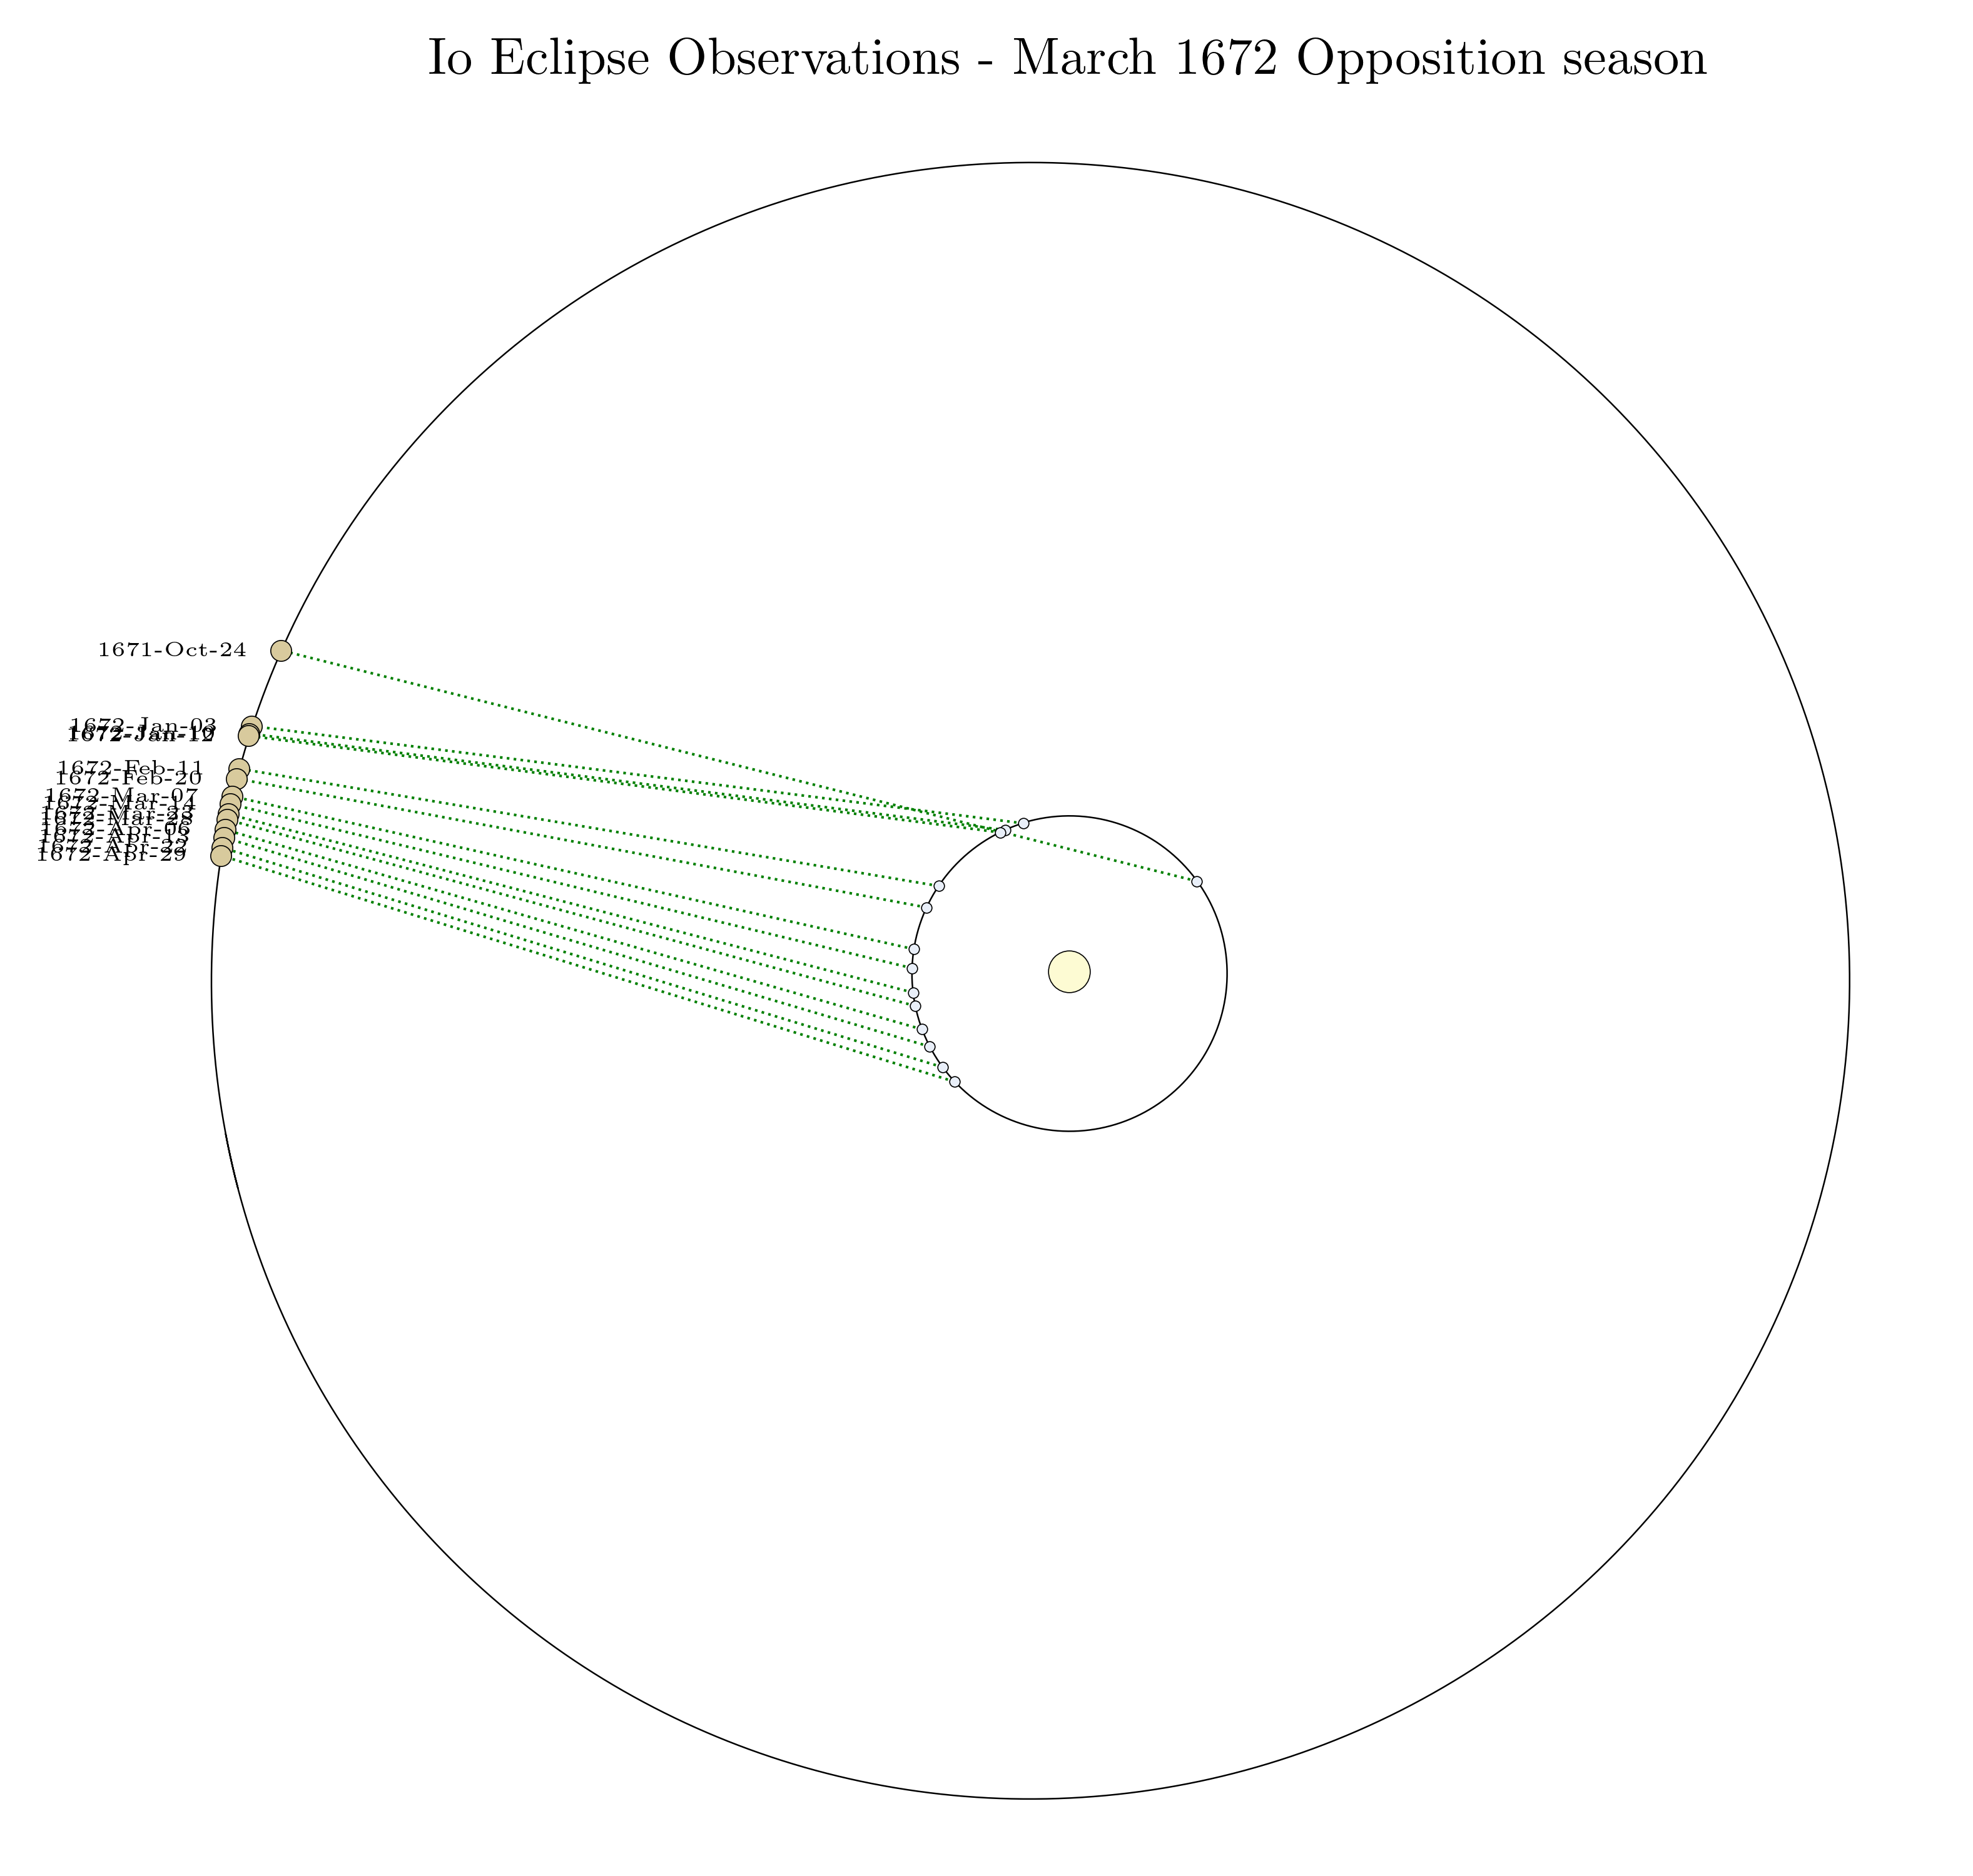

In [13]:
plotFile = 'EarthJupiter_Romer_1672.png'

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax.set_aspect(True)  

# 1:1 axis ratio

ax.set_xlim(-5.5,5.5)
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_ylim(-5.5,5.5)
ax.set_yticks([])
ax.set_yticklabels([])

ax.axis('off')

# plot the orbits of Earth and Jupiter

ax.plot(xEarth,yEarth,'-',color='black',lw=0.3,zorder=8)
ax.plot(xJupOrb,yJupOrb,'-',color='black',lw=0.3,zorder=8)

# Sun at the center

ax.plot(0,0,'o',ms=8,mfc='#fdfbd3',mec='black',mew=0.2,zorder=10)

# positions of Earth and Jupiter during Romer's observations

for i in range(num1672):
    ax.plot(xrE_1672[i],yrE_1672[i],'o',ms=2,mfc='#e9eff9',mec='black',mew=0.2,zorder=10)
    ax.plot(xrJ_1672[i],yrJ_1672[i],'o',ms=4,mfc='#d8ca9d',mec='black',mew=0.2,zorder=10)
    ax.plot([xrE_1672[i],xrJ_1672[i]],[yrE_1672[i],yrJ_1672[i]],':',color='green',lw=0.5,zorder=8)
    ax.text(xrJ_1672[i]-0.2,yrJ_1672[i],obsDate_1672[i],ha='right',va='center',fontsize=4)
    
ax.set_title('Io Eclipse Observations - March 1672 Opposition season',fontsize=axisFontSize)

# make the hardcopy

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

### 1673 April 2 Opposition

These data cover the opposition of 2 April 1673 and run from 28 Nov 1672 through 4 Aug 1673.


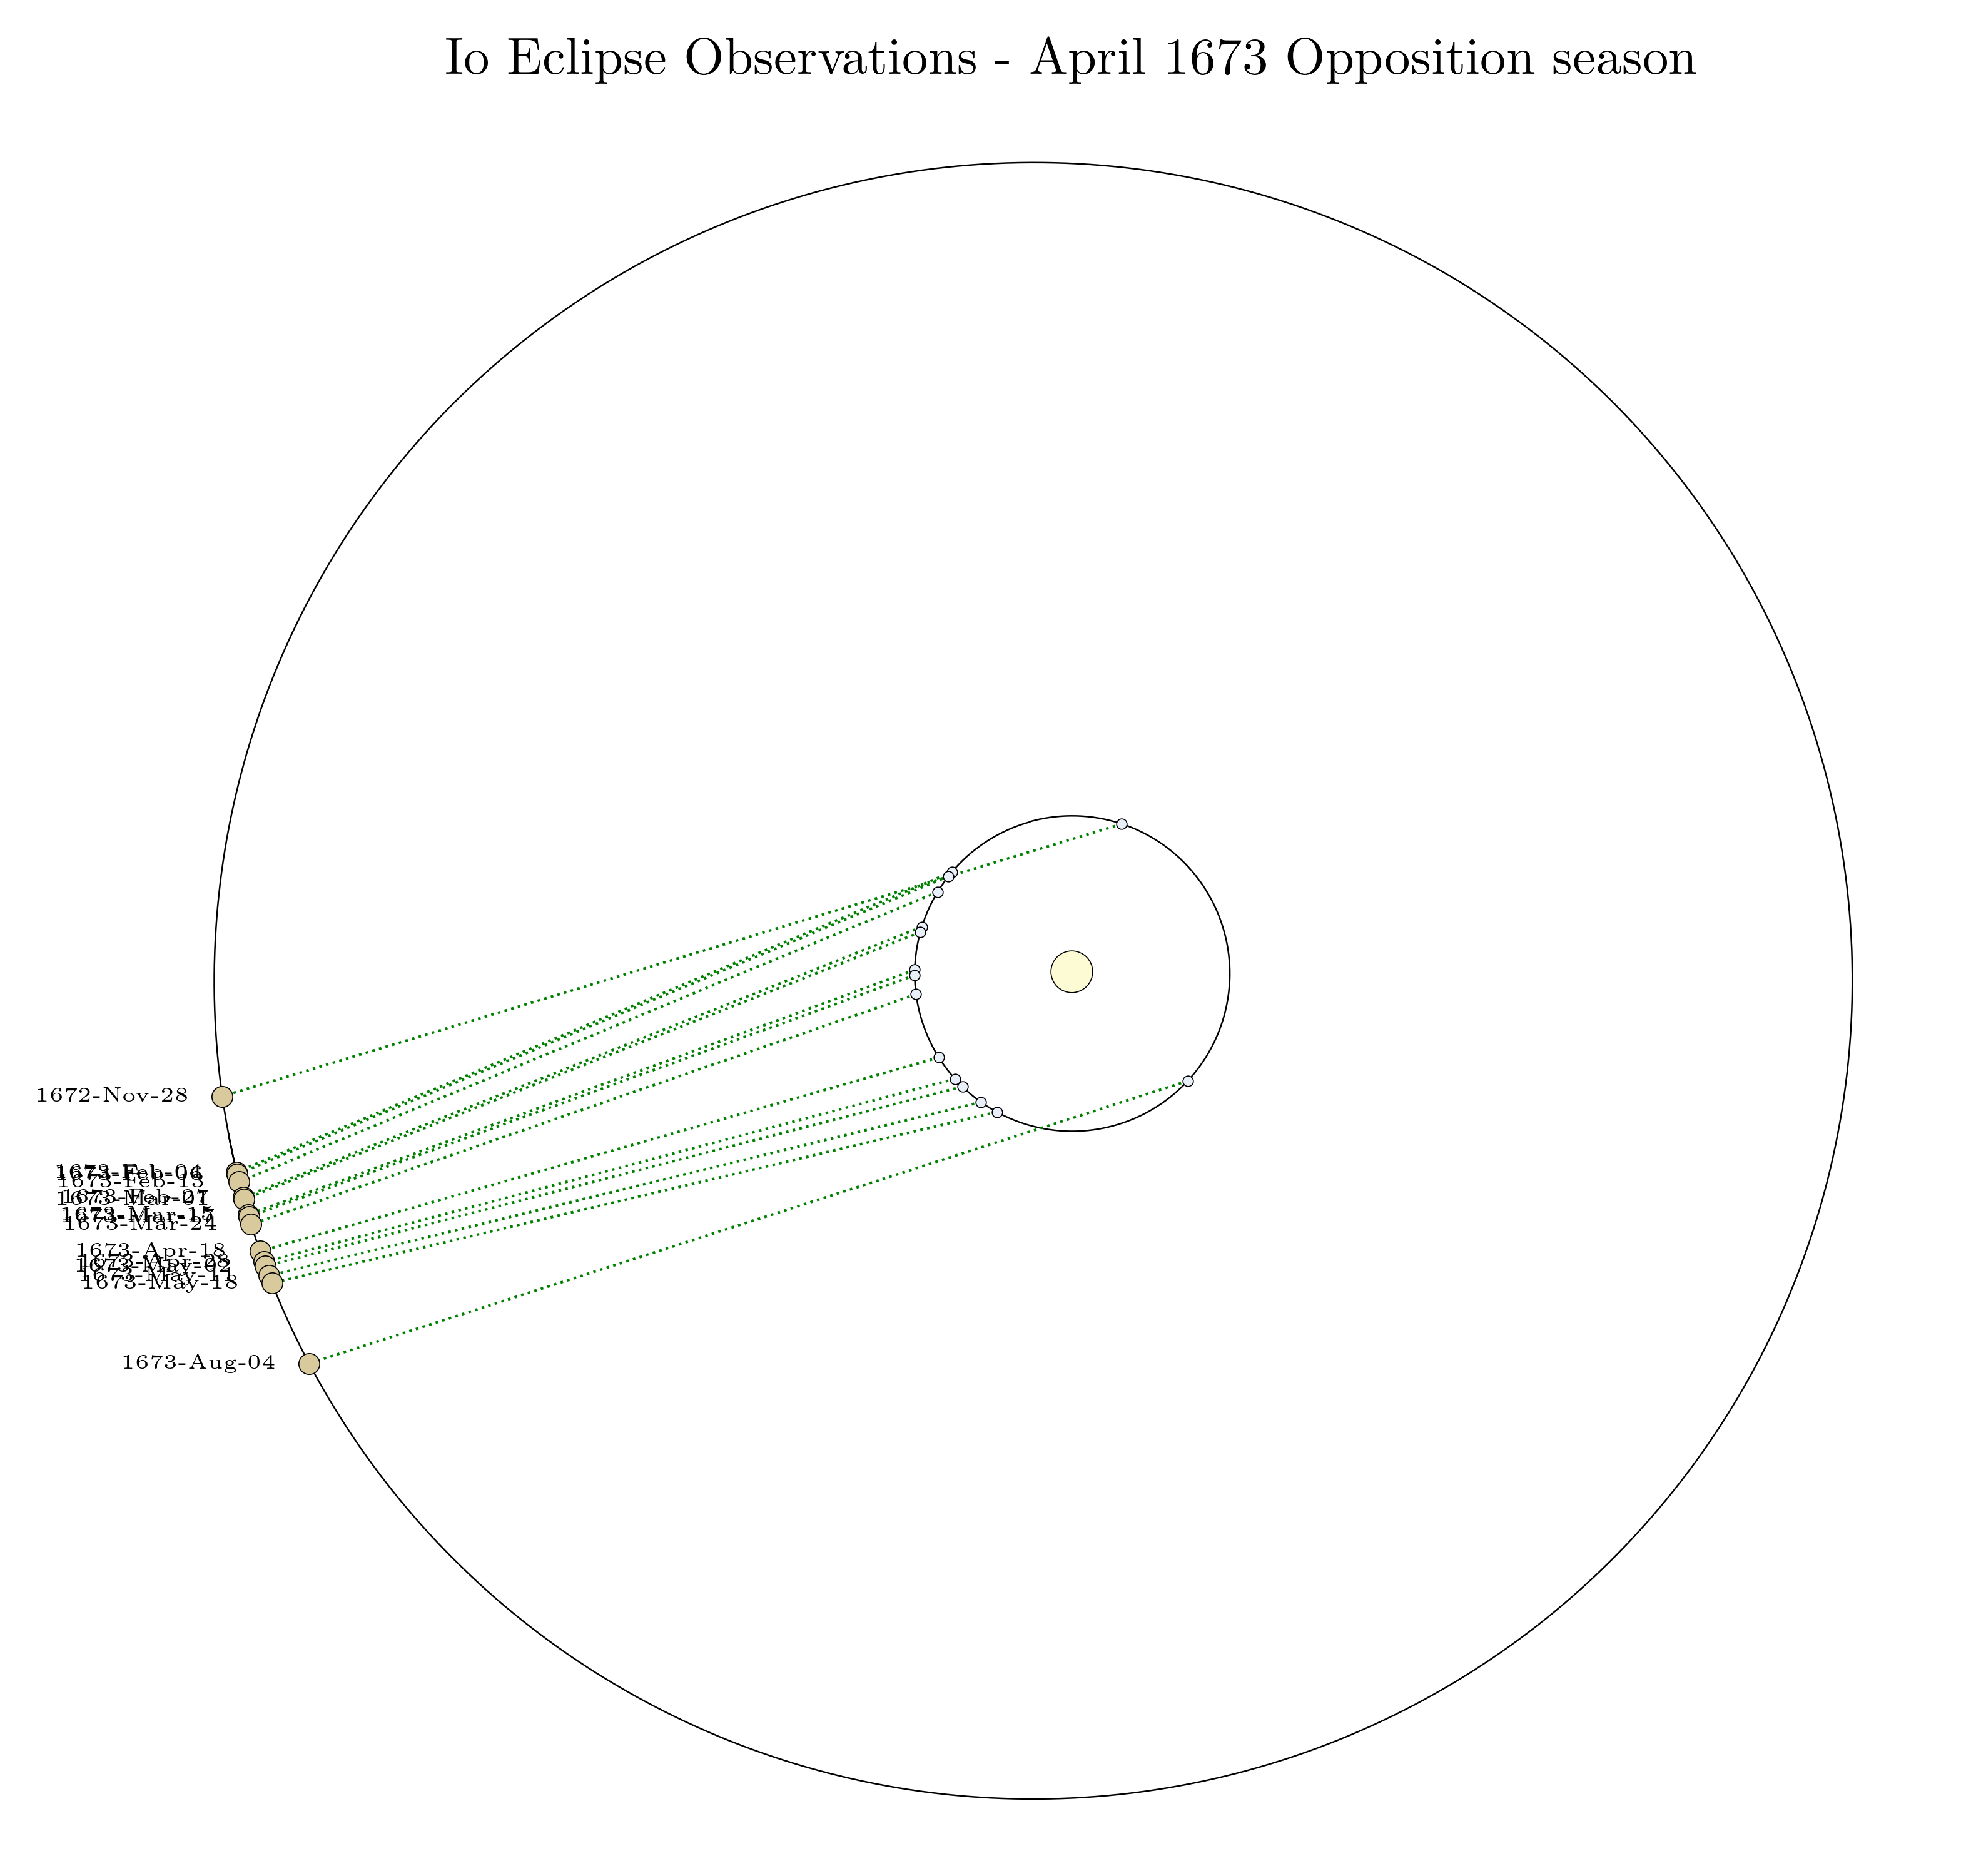

In [14]:
plotFile = 'EarthJupiter_Romer_1673.png'

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax.set_aspect(True)  

# 1:1 axis ratio

ax.set_xlim(-5.5,5.5)
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_ylim(-5.5,5.5)
ax.set_yticks([])
ax.set_yticklabels([])
ax.axis('off')

# plot the orbits of Earth and Jupiter

ax.plot(xEarth,yEarth,'-',color='black',lw=0.3,zorder=8)
ax.plot(xJupOrb,yJupOrb,'-',color='black',lw=0.3,zorder=8)

# Sun at the center

ax.plot(0,0,'o',ms=8,mfc='#fdfbd3',mec='black',mew=0.2,zorder=10)

# positions of Earth and Jupiter during Romer's observations

for i in range(num1673):
    ax.plot(xrE_1673[i],yrE_1673[i],'o',ms=2,mfc='#e9eff9',mec='black',mew=0.2,zorder=10)
    ax.plot(xrJ_1673[i],yrJ_1673[i],'o',ms=4,mfc='#d8ca9d',mec='black',mew=0.2,zorder=10)
    ax.plot([xrE_1673[i],xrJ_1673[i]],[yrE_1673[i],yrJ_1673[i]],':',color='green',lw=0.5,zorder=8)
    ax.text(xrJ_1673[i]-0.2,yrJ_1673[i],obsDate_1673[i],ha='right',va='center',fontsize=4)

ax.set_title('Io Eclipse Observations - April 1673 Opposition season',fontsize=axisFontSize)

# make the hardcopy

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')